## Implementation of an LSP method to automatize the building of a general oncology taxonomy
Main reference:
- Marti A. Hearst. 1992. Automatic Acquisition of Hyponyms from Large Text Corpora. In COLING 1992 Volume 2: The 14th International Conference on Computational Linguistics.

The goal is to implement a pipeline to extract hyponym-hypernym (IS-A) relations from text using the Hearst Patterns method, as described in Marti A. Hearst's paper. We will utilize the scispaCy library, which provides an implementation of the Hearst Patterns through the HyponymDetector component.
Our goal is to build a taxonomy of terms, specifically focusing on cancer-related terms, from a given text corpus.

Some observations:
- Pattern-Based Extraction: We use predefined lexico-syntactic patterns (Hearst Patterns) to extract hyponym-hypernym relations, as described in the paper.
- No Prior Lexical Knowledge: The extraction is done without relying on prior knowledge of specific terms, aligning with the method's goal of - discovering relations directly from text.
- Limitations: As observed in Hearst's paper, the method may extract relations that are too general or context-specific. Post-processing or manual validation may be necessary to refine the taxonomy.
- Automated Acquisition: The pipeline demonstrates automatic acquisition of lexical relations from a corpus, showcasing the practicality of Hearst's approach.

#### Imports
- spacy: An open-source NLP library for advanced natural language processing.
- scispacy: A spaCy extension tailored for scientific and biomedical text processing.
- HyponymDetector: A component from scispacy that implements the Hearst Patterns for hyponym-hypernym extraction.
- networkx: A Python library for creating and manipulating complex networks and graphs.
- matplotlib.pyplot: A plotting library used for visualization.

In [2]:
import spacy
from spacy.matcher import Matcher
import networkx as nx
import matplotlib.pyplot as plt

In [14]:
# Load the spaCy model and add the HyponymDetector to the pipeline
nlp = spacy.load("en_core_sci_sm")
#nlp.add_pipe("hyponym_detector", last=True, config={"extended": True})  # Use extended=True for more patterns

In [15]:
from lsp_patterns import LSP_PATTERNS
import spacy
def extract_hyponyms(text):
    hyponym_relations = []
    doc = nlp(text)
    matcher = Matcher(nlp.vocab)

    patterns = LSP_PATTERNS
    
    for pat in patterns:
        matcher.add(pat["label"], [pat["pattern"]])

    matches = matcher(doc)
    for match_id, start, end in matches:
        span = doc[start:end]
        label = nlp.vocab.strings[match_id]

        # Initialize variables
        hypernym_tokens = []
        hyponym_tokens = []
        cue_indices = []

        # Identify the positions of the cue words
        cue_word = ''
        if label == "such_as":
            for idx in range(len(span) - 1):
                if span[idx].lower_ == 'such':
                    # Skip over punctuation
                    next_idx = idx + 1
                    while next_idx < len(span) and span[next_idx].is_punct:
                        next_idx += 1
                    if next_idx < len(span) and span[next_idx].lower_ == 'as':
                        cue_indices.extend([idx, next_idx])
                        cue_word = 'such as'
                        break
        elif label in ["including", "especially", "like"]:
            for idx, token in enumerate(span):
                if token.lower_ == label:
                    cue_indices.append(idx)
                    cue_word = label
                    break

        if not cue_indices:
            continue  # Skip if cue words are not found

        # Split the span into hypernym and hyponym tokens
        hypernym_tokens = span[:cue_indices[0]]
        hyponym_tokens = span[cue_indices[-1] + 1:]

        # Remove leading or trailing punctuation from hypernym and hyponym tokens
        hypernym_tokens = [t for t in hypernym_tokens if not t.is_punct]
        hyponym_tokens = [t for t in hyponym_tokens if not t.is_punct]

        # Extract hypernym and hyponyms
        hypernym = " ".join([t.text for t in hypernym_tokens]).strip()
        hyponym_text = " ".join([t.text for t in hyponym_tokens]).strip()

        # Split hyponyms by commas and conjunctions
        hyponyms = []
        current_hyponym = []
        for token in hyponym_tokens:
            if token.text.lower() in [",", "and", "or"]:
                if current_hyponym:
                    hyponym_str = " ".join([t.text for t in current_hyponym]).strip()
                    hyponyms.append(hyponym_str)
                    current_hyponym = []
            else:
                current_hyponym.append(token)
        if current_hyponym:
            hyponym_str = " ".join([t.text for t in current_hyponym]).strip()
            hyponyms.append(hyponym_str)

        # Avoid duplicates by using a set
        hyponyms = list(set(hyponyms))

        # Append each hyponym with the hypernym and relation
        for hyponym in hyponyms:
            hyponym_relations.append((hyponym, hypernym, label))

    # Remove duplicate hyponym-hypernym pairs
    hyponym_relations = list(set(hyponym_relations))

    return hyponym_relations

In [16]:
def filter_relations(hyponym_relations):
    # First, filter hyponyms as before
    # Organize hyponyms by hypernym
    hypernym_to_hyponyms = {}
    relation_dict = {}
    for hyponym, hypernym, relation in hyponym_relations:
        if hypernym not in hypernym_to_hyponyms:
            hypernym_to_hyponyms[hypernym] = set()
            relation_dict[hypernym] = {}
        hypernym_to_hyponyms[hypernym].add(hyponym)
        relation_dict[hypernym][hyponym] = relation

    # Filter hyponyms for each hypernym
    filtered_hyponym_relations = []
    for hypernym, hyponyms in hypernym_to_hyponyms.items():
        hyponym_list = list(hyponyms)
        hyponyms_to_remove = set()
        for i, hyponym_i in enumerate(hyponym_list):
            for j, hyponym_j in enumerate(hyponym_list):
                if i != j and hyponym_i.lower() in hyponym_j.lower():
                    if len(hyponym_i) < len(hyponym_j):
                        hyponyms_to_remove.add(hyponym_i)
        filtered_hyponyms = [h for h in hyponym_list if h not in hyponyms_to_remove]
        for hyponym in filtered_hyponyms:
            relation = relation_dict[hypernym][hyponym]
            filtered_hyponym_relations.append((hyponym, hypernym, relation))

    # Now, filter hypernyms for each hyponym
    # Organize hypernyms by hyponym
    hyponym_to_hypernyms = {}
    relation_dict_hypernyms = {}
    for hyponym, hypernym, relation in filtered_hyponym_relations:
        if hyponym not in hyponym_to_hypernyms:
            hyponym_to_hypernyms[hyponym] = set()
            relation_dict_hypernyms[hyponym] = {}
        hyponym_to_hypernyms[hyponym].add(hypernym)
        relation_dict_hypernyms[hyponym][hypernym] = relation

    # Filter hypernyms for each hyponym
    final_relations = []
    for hyponym, hypernyms in hyponym_to_hypernyms.items():
        hypernym_list = list(hypernyms)
        hypernyms_to_remove = set()
        for i, hypernym_i in enumerate(hypernym_list):
            for j, hypernym_j in enumerate(hypernym_list):
                if i != j and hypernym_i.lower() in hypernym_j.lower():
                    if len(hypernym_i) < len(hypernym_j):
                        hypernyms_to_remove.add(hypernym_i)
        filtered_hypernyms = [h for h in hypernym_list if h not in hypernyms_to_remove]
        for hypernym in filtered_hypernyms:
            relation = relation_dict_hypernyms[hyponym][hypernym]
            final_relations.append((hyponym, hypernym, relation))

    return final_relations


In [17]:

def build_taxonomy(hyponym_relations):
    G = nx.DiGraph()
    for hyponym, hypernym, relation_rule in hyponym_relations:
        G.add_edge(hypernym, hyponym, relation=relation_rule)
    return G

def visualize_taxonomy(G):
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.5)
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightgreen', font_size=10, arrows=True)
    edge_labels = nx.get_edge_attributes(G, 'relation')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    plt.title('Taxonomy Visualization with Lexical Links')
    plt.show()

Here we try the method with a really small text extract to test the implementation:

In [18]:

# Sample text containing cancer-related and non-cancer-related sentences
text = """
Carcinomas such as basal cell carcinoma, squamous cell carcinoma, and adenocarcinoma are common
Leukemia, including acute lymphoblastic leukemia and chronic lymphocytic leukemia, affects the blood and bone marrow.
There are many types of sarcomas, especially osteosarcoma and chondrosarcoma.
Germ cell tumors, such as seminoma and teratoma, originate from germ cells.
Lymphomas, including Hodgkin lymphoma and non-Hodgkin lymphoma, affect the lymphatic system.
Some cancers, like pancreatic cancer, lung cancer, or other deadly diseases, have high mortality rates.
Tumors, especially malignant ones like glioblastoma and astrocytoma, are dangerous.
Breast cancers, including ductal carcinoma and lobular carcinoma, are common in women.
The study explores non-cancerous conditions such as diabetes, hypertension, and other metabolic disorders.
Advancements in technology such as artificial intelligence and machine learning are transforming healthcare.
"""


Hyponym Relations with Lexical Links:
hyponym('adenocarcinoma', 'Carcinomas') - relation: 'such_as'
hyponym('basal cell carcinoma squamous cell carcinoma', 'Carcinomas') - relation: 'such_as'
hyponym('pancreatic cancer lung cancer', 'cancers') - relation: 'like'
hyponym('lobular carcinoma', 'Breast cancers') - relation: 'including'
hyponym('other deadly diseases', 'cancers') - relation: 'like'
hyponym('ductal carcinoma', 'Breast cancers') - relation: 'including'
hyponym('other metabolic disorders', 'non-cancerous conditions') - relation: 'such_as'
hyponym('diabetes hypertension', 'non-cancerous conditions') - relation: 'such_as'
hyponym('astrocytoma', 'malignant ones') - relation: 'like'
hyponym('glioblastoma', 'malignant ones') - relation: 'like'
hyponym('malignant ones', 'Tumors') - relation: 'especially'
hyponym('non-Hodgkin lymphoma', 'Lymphomas') - relation: 'including'
hyponym('seminoma', 'Germ cell tumors') - relation: 'such_as'
hyponym('teratoma originate', 'Germ cell tumors') 

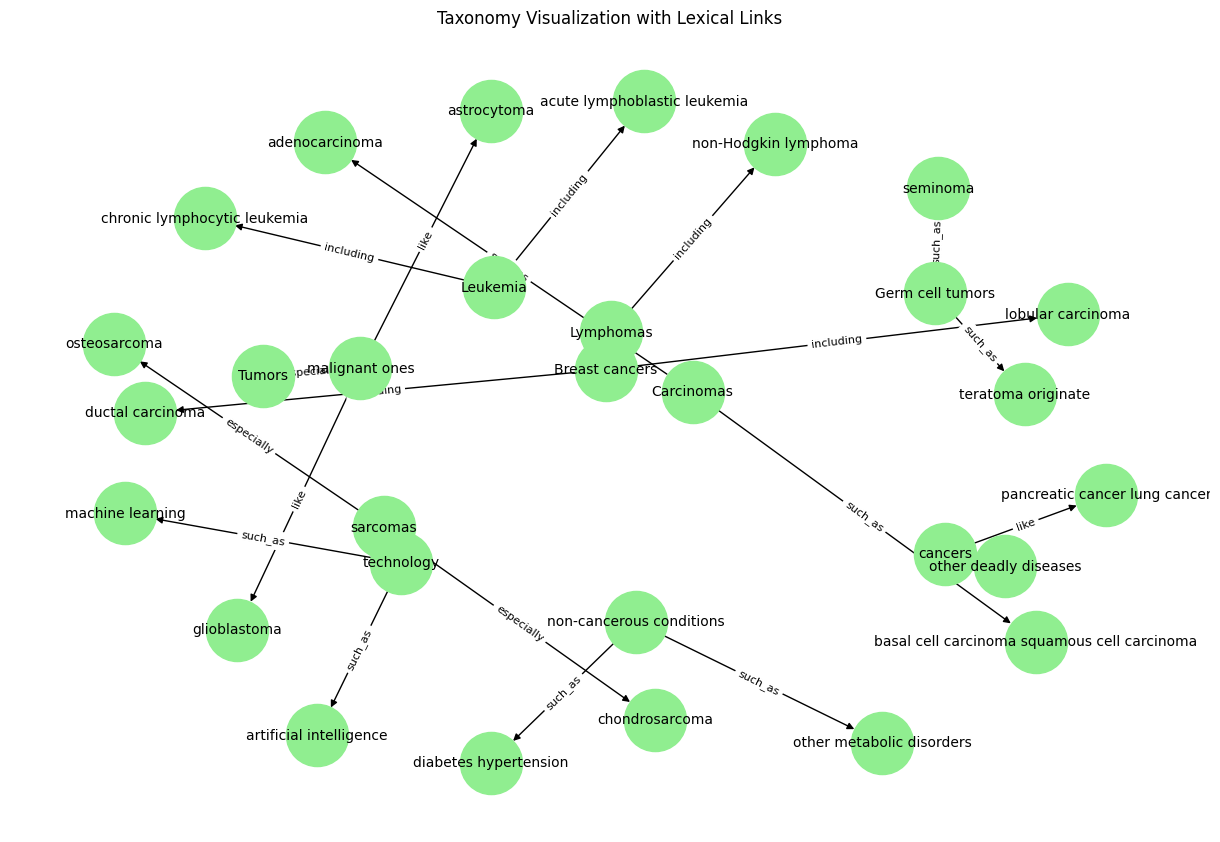

In [19]:
# Extract hyponym relations
hyponym_relations = extract_hyponyms(text)

# Filter hyponyms to keep only the longest ones
hyponym_relations_filtered = filter_relations(hyponym_relations)

# Build the taxonomy graph
G = build_taxonomy(hyponym_relations_filtered)

# Print the hyponym relations with their lexical links
print("Hyponym Relations with Lexical Links:")
for hyponym, hypernym, relation_rule in hyponym_relations_filtered:
    print(f"hyponym('{hyponym}', '{hypernym}') - relation: '{relation_rule}'")

# Visualize the taxonomy with lexical links
visualize_taxonomy(G)

### Next Steps
1. Implement Filtering for Domain Focus:
- Add a filtering step to focus the taxonomy on cancer-related terms.
- This can be done by checking if either the hyponym or hypernym contains cancer-related keywords.
2. Expand the Corpus:
- Use a larger and more diverse text corpus, such as PubMed abstracts, to build a more comprehensive taxonomy.
3. Evaluate and Refine the Taxonomy:
- Find metrics of evaluation to compare with the NCIt
